<a href="https://colab.research.google.com/github/JananiGovuri/Natural-Language-Processing-/blob/main/HW4_Code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# ---- Sample Toy Data ----
text = "hello help hello hero hello hill hello help hello"
chars = sorted(list(set(text)))

# Create mappings
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

vocab_size = len(chars)

# Encode text
data = [char2idx[ch] for ch in text]

# ---- Hyperparameters ----
hidden_size = 128
seq_length = 20
learning_rate = 0.003
epochs = 10

# ---- Model Definition ----
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CharRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

# Initialize model
model = CharRNN(vocab_size, hidden_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ---- Training ----
for epoch in range(epochs):
    total_loss = 0
    hidden = None

    for i in range(0, len(data) - seq_length):
        seq_in = data[i:i+seq_length]
        seq_out = data[i+1:i+seq_length+1]

        inputs = torch.tensor(seq_in).unsqueeze(0)
        targets = torch.tensor(seq_out)

        optimizer.zero_grad()

        outputs, hidden = model(inputs, hidden)
        hidden = (hidden[0].detach(), hidden[1].detach())

        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ---- Text Generation ----
def generate_text(model, start_str, length=100, temperature=1.0):
    model.eval()
    input_seq = torch.tensor([char2idx[ch] for ch in start_str]).unsqueeze(0)
    hidden = None

    result = start_str

    for _ in range(length):
        output, hidden = model(input_seq, hidden)
        logits = output[:, -1, :] / temperature
        probs = torch.softmax(logits, dim=1).detach().numpy()[0]

        next_char = random.choices(range(vocab_size), weights=probs)[0]
        result += idx2char[next_char]

        input_seq = torch.tensor([[next_char]])

    return result

# ---- Generate Samples ----
print("\nSample (τ=0.7):")
print(generate_text(model, "he", 100, temperature=0.7))

print("\nSample (τ=1.0):")
print(generate_text(model, "he", 100, temperature=1.0))

print("\nSample (τ=1.2):")
print(generate_text(model, "he", 100, temperature=1.2))

Epoch 1, Loss: 21.3934
Epoch 2, Loss: 9.9590
Epoch 3, Loss: 9.0197
Epoch 4, Loss: 8.1038
Epoch 5, Loss: 6.9257
Epoch 6, Loss: 6.2002
Epoch 7, Loss: 5.9885
Epoch 8, Loss: 5.4771
Epoch 9, Loss: 5.1310
Epoch 10, Loss: 5.0510

Sample (τ=0.7):
hero hello hill hello hill hello hero hello hill hello hero hello help hello hill hello hero hello hil

Sample (τ=1.0):
hello hero hello hello help hello hill hello hill hello hill hill hello hill hello hill hello hill hel

Sample (τ=1.2):
help hill hello help hello hello ho hello hill hello hero hello hill hello hill hello help hello hill 


Input Tokens:
 tensor([[ 9, 19,  1,  0],
        [ 8, 18, 14,  0],
        [10, 22,  0,  6],
        [15,  0,  5,  0],
        [ 1,  0, 16,  0],
        [ 9,  7, 22,  0],
        [11,  0, 20,  4],
        [13, 19, 17,  0],
        [ 3, 21,  2,  0],
        [12,  0,  5,  0]])

Final Contextual Embeddings Shape: torch.Size([10, 4, 32])


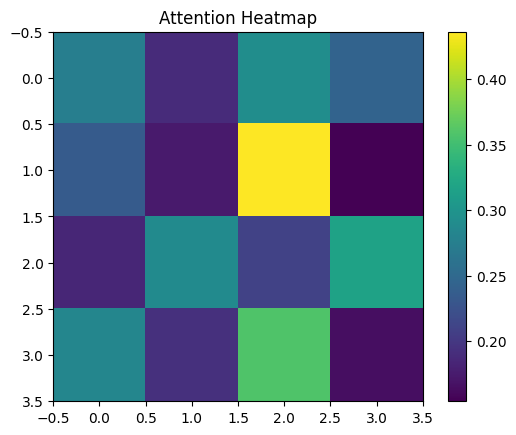

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

# -------------------------------
# 1. Sample Dataset (10 sentences)
# -------------------------------
sentences = [
    "i love nlp",
    "transformers are powerful",
    "deep learning is fun",
    "attention is important",
    "nlp is interesting",
    "i enjoy learning",
    "this is a model",
    "we love ai",
    "models learn patterns",
    "data is important"
]

# -------------------------------
# 2. Tokenization
# -------------------------------
words = list(set(" ".join(sentences).split()))
word2idx = {w: i for i, w in enumerate(words)}
idx2word = {i: w for w, i in word2idx.items()}

def tokenize(sentence):
    return [word2idx[w] for w in sentence.split()]

tokenized_data = [tokenize(s) for s in sentences]

# Padding
max_len = max(len(seq) for seq in tokenized_data)

def pad(seq):
    return seq + [0]*(max_len - len(seq))

inputs = torch.tensor([pad(seq) for seq in tokenized_data])

print("Input Tokens:\n", inputs)

# -------------------------------
# 3. Embedding Layer
# -------------------------------
d_model = 32
embedding = nn.Embedding(len(words), d_model)
x = embedding(inputs)

# -------------------------------
# 4. Positional Encoding
# -------------------------------
def positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = math.sin(pos / (10000 ** ((2*i)/d_model)))
            pe[pos, i+1] = math.cos(pos / (10000 ** ((2*i)/d_model)))
    return pe

pe = positional_encoding(max_len, d_model)
x = x + pe

# -------------------------------
# 5. Multi-Head Attention
# -------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads=2):
        super().__init__()
        self.heads = heads
        self.d_k = d_model // heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.size()

        Q = self.q_linear(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        K = self.k_linear(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        V = self.v_linear(x).view(B, T, self.heads, self.d_k).transpose(1,2)

        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)
        out = out.transpose(1,2).contiguous().view(B, T, C)
        return self.out(out), attn

# -------------------------------
# 6. Feed Forward Layer
# -------------------------------
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 64)
        self.fc2 = nn.Linear(64, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

# -------------------------------
# 7. Transformer Encoder Block
# -------------------------------
class EncoderBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn = MultiHeadAttention(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x, attn_weights

# -------------------------------
# 8. Run Encoder
# -------------------------------
encoder = EncoderBlock(d_model)
output, attn_weights = encoder(x)

print("\nFinal Contextual Embeddings Shape:", output.shape)

# -------------------------------
# 9. Attention Heatmap
# -------------------------------
# Show attention for first sentence, first head
heatmap = attn_weights[0][0].detach().numpy()

plt.imshow(heatmap, cmap='viridis')
plt.title("Attention Heatmap")
plt.colorbar()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
import math

# -------------------------------
# 1. Scaled Dot-Product Attention Function
# -------------------------------
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)

    # Compute raw scores
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # Without scaling (for comparison)
    unscaled_softmax = F.softmax(scores, dim=-1)

    # Apply scaling
    scaled_scores = scores / math.sqrt(d_k)

    # Softmax after scaling
    attn_weights = F.softmax(scaled_scores, dim=-1)

    # Final output
    output = torch.matmul(attn_weights, V)

    return output, attn_weights, scores, scaled_scores, unscaled_softmax

# -------------------------------
# 2. Test with Random Q, K, V
# -------------------------------
torch.manual_seed(0)

batch_size = 1
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

# Run attention
output, attn_weights, scores, scaled_scores, unscaled_softmax = scaled_dot_product_attention(Q, K, V)

# -------------------------------
# 3. Print Results
# -------------------------------
print("=== Raw Scores (QK^T) ===")
print(scores)

print("\n=== Softmax WITHOUT Scaling ===")
print(unscaled_softmax)

print("\n=== Scaled Scores ===")
print(scaled_scores)

print("\n=== Attention Weights (WITH Scaling) ===")
print(attn_weights)

print("\n=== Output Vectors ===")
print(output)

=== Raw Scores (QK^T) ===
tensor([[[-0.0146,  5.1091, -0.3921, -3.7779],
         [ 0.4648,  0.5446, -0.7034,  0.9571],
         [ 1.3816, -7.0338, -0.2771,  2.2690],
         [ 0.6756,  3.8463, -1.2603, -2.3062]]])

=== Softmax WITHOUT Scaling ===
tensor([[[5.8939e-03, 9.8993e-01, 4.0409e-03, 1.3678e-04],
         [2.4813e-01, 2.6875e-01, 7.7146e-02, 4.0597e-01],
         [2.7628e-01, 6.1181e-05, 5.2604e-02, 6.7106e-01],
         [3.9970e-02, 9.5224e-01, 5.7673e-03, 2.0266e-03]]])

=== Scaled Scores ===
tensor([[[-0.0052,  1.8063, -0.1386, -1.3357],
         [ 0.1643,  0.1926, -0.2487,  0.3384],
         [ 0.4885, -2.4868, -0.0980,  0.8022],
         [ 0.2389,  1.3599, -0.4456, -0.8154]]])

=== Attention Weights (WITH Scaling) ===
tensor([[[0.1211, 0.7410, 0.1060, 0.0320],
         [0.2577, 0.2651, 0.1705, 0.3067],
         [0.3360, 0.0171, 0.1869, 0.4599],
         [0.2032, 0.6235, 0.1025, 0.0708]]])

=== Output Vectors ===
tensor([[[-1.2940, -0.1495, -0.3701, -0.2156, -0.9138,  1.06